Daily Challenge: Logistic Regression for Admission Prediction

=== Aperçu des données ===
       Exam1      Exam2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1

Shape : (100, 3)

Valeurs manquantes :
Exam1       0
Exam2       0
Admitted    0
dtype: int64

Distribution admis/non admis :
Admitted
1    60
0    40
Name: count, dtype: int64


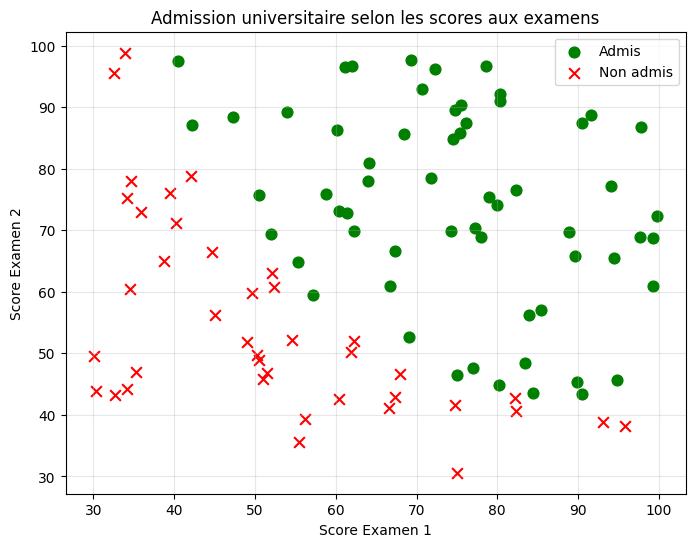


Commentaire scatter plot :
On voit clairement deux groupes séparés.
Les étudiants admis (vert) ont globalement des scores
plus élevés aux deux examens que les non admis (rouge).
La séparation entre les deux groupes suggère qu'une
régression logistique peut bien fonctionner ici.

Données entraînement : 80 lignes
Données test         : 20 lignes

Entraînement terminé 

=== Accuracy ===
Accuracy : 80.00%

=== Rapport de classification ===
              precision    recall  f1-score   support

   Non admis       0.70      0.88      0.78         8
       Admis       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20


Commentaire résultats :
- Accuracy de 80.00% : le modèle prédit correctement
  80.00% des cas sur les données de test.
- Ce dataset est relativement équilibré donc l'accuracy
  est une métrique fiable ici contrairement au dataset d

e:\FORMATION_Tech_Talent_Accelerator_de_initiative_FORPRODE\DI_Bootcamp\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


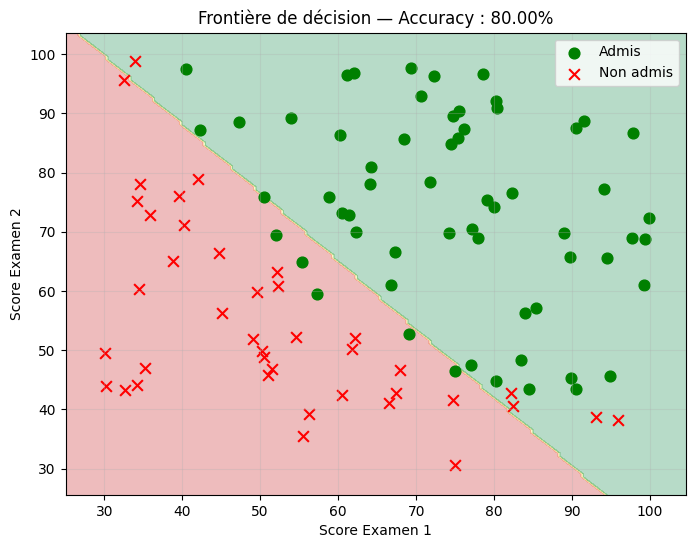

In [2]:
# Daily Challenge : Logistic Regression for Admission Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# 1. Chargement et exploration des données

url = r"E:\FORMATION_Tech_Talent_Accelerator_de_initiative_FORPRODE\DI_Bootcamp\Week4\Day2\DailyChallenge\ex2data1.txt"
df = pd.read_csv(url, header=None, names=['Exam1', 'Exam2', 'Admitted'])

print("=== Aperçu des données ===")
print(df.head())
print(f"\nShape : {df.shape}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
print(f"\nDistribution admis/non admis :\n{df['Admitted'].value_counts()}")

# 2. Visualisation — Scatter plot

plt.figure(figsize=(8, 6))

# Admis (1) en vert
admitted = df[df['Admitted'] == 1]
plt.scatter(admitted['Exam1'], admitted['Exam2'],
            c='green', label='Admis', marker='o', s=60)

# Non admis (0) en rouge
not_admitted = df[df['Admitted'] == 0]
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'],
            c='red', label='Non admis', marker='x', s=60)

plt.xlabel('Score Examen 1')
plt.ylabel('Score Examen 2')
plt.title('Admission universitaire selon les scores aux examens')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("""
Commentaire scatter plot :
On voit clairement deux groupes séparés.
Les étudiants admis (vert) ont globalement des scores
plus élevés aux deux examens que les non admis (rouge).
La séparation entre les deux groupes suggère qu'une
régression logistique peut bien fonctionner ici.
""")


# 3. Préparation des données

X = df[['Exam1', 'Exam2']]
y = df['Admitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Données entraînement : {X_train.shape[0]} lignes")
print(f"Données test         : {X_test.shape[0]} lignes")


# 4. Entraînement du modèle

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
print("\nEntraînement terminé ")


# 5. Prédictions et Accuracy

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n=== Accuracy ===")
print(f"Accuracy : {accuracy:.2%}")


# 6. Évaluation du modèle

print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred,
      target_names=['Non admis', 'Admis']))

print(f"""
Commentaire résultats :
- Accuracy de {accuracy:.2%} : le modèle prédit correctement
  {accuracy:.2%} des cas sur les données de test.
- Ce dataset est relativement équilibré donc l'accuracy
  est une métrique fiable ici contrairement au dataset diabète.
- Les deux scores d'examens sont suffisants pour prédire
  l'admission avec une bonne fiabilité.
- La régression logistique est bien adaptée ici car le problème
  est une classification binaire : admis (1) ou non admis (0).
""")

# 7. Visualisation de la frontière de décision

x_min, x_max = X['Exam1'].min() - 5, X['Exam1'].max() + 5
y_min, y_max = X['Exam2'].min() - 5, X['Exam2'].max() + 5
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 0.5)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.scatter(admitted['Exam1'], admitted['Exam2'],
            c='green', label='Admis', marker='o', s=60)
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'],
            c='red', label='Non admis', marker='x', s=60)
plt.xlabel('Score Examen 1')
plt.ylabel('Score Examen 2')
plt.title(f'Frontière de décision — Accuracy : {accuracy:.2%}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()